# Exercise 1D: Momentum Decile Portfolios
**BUSI 722: Data-Driven Finance II**

Using the momentum decile assignments from Exercise 1C, construct and evaluate
momentum portfolios. Compute cumulative returns, Sharpe ratios, and a
long-short portfolio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("exercise01_data_with_deciles.parquet")
print(f"Loaded: {len(df):,} rows, {df['ticker'].nunique()} tickers")
print(f"Date range: {df['month'].min()} to {df['month'].max()}")

Loaded: 127,863 rows, 4758 tickers
Date range: 2023-01 to 2026-01


## 1. Compute Cumulative Returns by Decile

Each month, compute the equal-weighted mean return for each momentum decile
portfolio, then compute cumulative returns from January 2023 through
January 2026.

In [3]:
decile_returns = df.groupby(["month", "mom_decile"])["return"].mean().reset_index()

decile_wide = decile_returns.pivot(
    index="month", columns="mom_decile", values="return"
).sort_index()

cumulative = (1 + decile_wide).cumprod()

print("Final cumulative return (growth of $1) by decile:")
for col in cumulative.columns:
    print(f"  Decile {int(col):2d}: ${cumulative[col].iloc[-1]:.4f}")

Final cumulative return (growth of $1) by decile:
  Decile  1: $2.0839
  Decile  2: $1.8053
  Decile  3: $1.8196
  Decile  4: $1.7159
  Decile  5: $1.5646
  Decile  6: $1.5692
  Decile  7: $1.7050
  Decile  8: $1.5849
  Decile  9: $1.6224
  Decile 10: $2.2860


## 2. Plot Cumulative Returns (Log Scale)

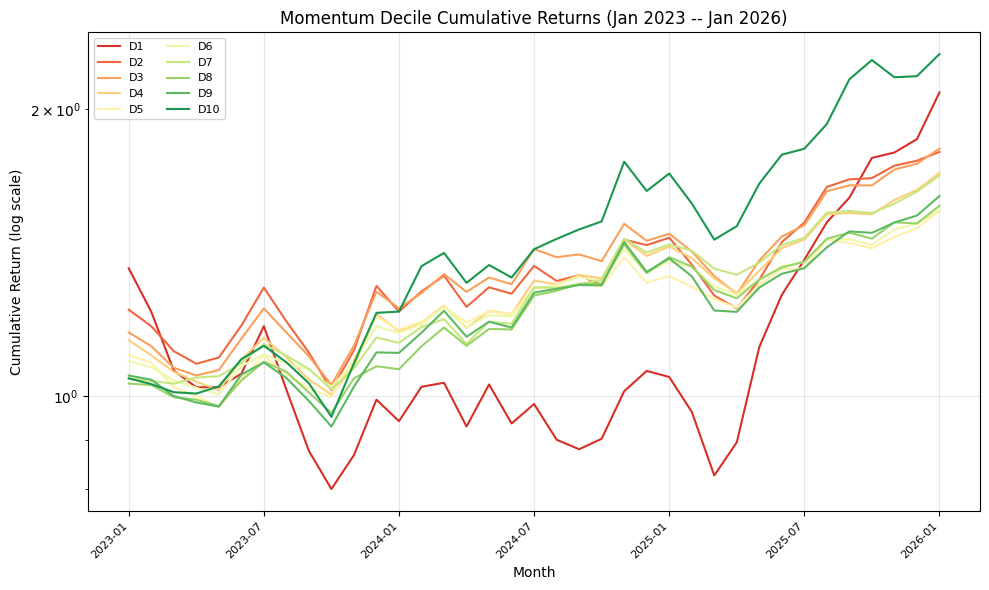

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

cmap = plt.cm.RdYlGn(np.linspace(0.1, 0.9, 10))
for i, col in enumerate(cumulative.columns):
    ax.plot(
        range(len(cumulative)), cumulative[col],
        label=f"D{int(col)}", color=cmap[i], linewidth=1.5
    )

ax.set_yscale("log")
ax.set_xlabel("Month")
ax.set_ylabel("Cumulative Return (log scale)")
ax.set_title("Momentum Decile Cumulative Returns (Jan 2023 -- Jan 2026)")
ax.legend(ncol=2, fontsize=8, loc="upper left")

tick_positions = list(range(0, len(cumulative), 6))
tick_labels = [cumulative.index[i] for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Annualized Sharpe Ratios

Sharpe ratio (assuming risk-free rate = 0):

$$\text{SR} = \frac{\bar{r}}{\sigma_r} \times \sqrt{12}$$

In [5]:
print("Annualized Sharpe ratios by momentum decile:")
print(f"{'Decile':>8s} {'Mean Mo':>10s} {'Std Mo':>10s} {'Ann SR':>10s}")
print("-" * 40)
for col in decile_wide.columns:
    mean_r = decile_wide[col].mean()
    std_r = decile_wide[col].std()
    sr = mean_r / std_r * np.sqrt(12)
    print(f"  D{int(col):2d}    {mean_r:10.4f} {std_r:10.4f} {sr:10.3f}")

Annualized Sharpe ratios by momentum decile:
  Decile    Mean Mo     Std Mo     Ann SR
----------------------------------------
  D 1        0.0259     0.1129      0.795
  D 2        0.0186     0.0733      0.879
  D 3        0.0180     0.0598      1.042
  D 4        0.0160     0.0527      1.053
  D 5        0.0132     0.0456      0.999
  D 6        0.0130     0.0398      1.132
  D 7        0.0152     0.0379      1.390
  D 8        0.0134     0.0417      1.110
  D 9        0.0143     0.0492      1.009
  D10        0.0245     0.0635      1.336


## 4. Long-Short Portfolio (Decile 10 minus Decile 1)

In [6]:
ls = decile_wide[10] - decile_wide[1]
ls_mean = ls.mean()
ls_std = ls.std()
ls_ann_mean = ls_mean * 12
ls_ann_sr = ls_mean / ls_std * np.sqrt(12)

print("Long-Short Portfolio (D10 - D1):")
print(f"  Mean monthly return:    {ls_mean:.4f}")
print(f"  Annualized mean return: {ls_ann_mean:.4f}  ({ls_ann_mean:.2%})")
print(f"  Monthly volatility:     {ls_std:.4f}")
print(f"  Annualized Sharpe:      {ls_ann_sr:.3f}")

Long-Short Portfolio (D10 - D1):
  Mean monthly return:    -0.0014
  Annualized mean return: -0.0170  (-1.70%)
  Monthly volatility:     0.0836
  Annualized Sharpe:      -0.059


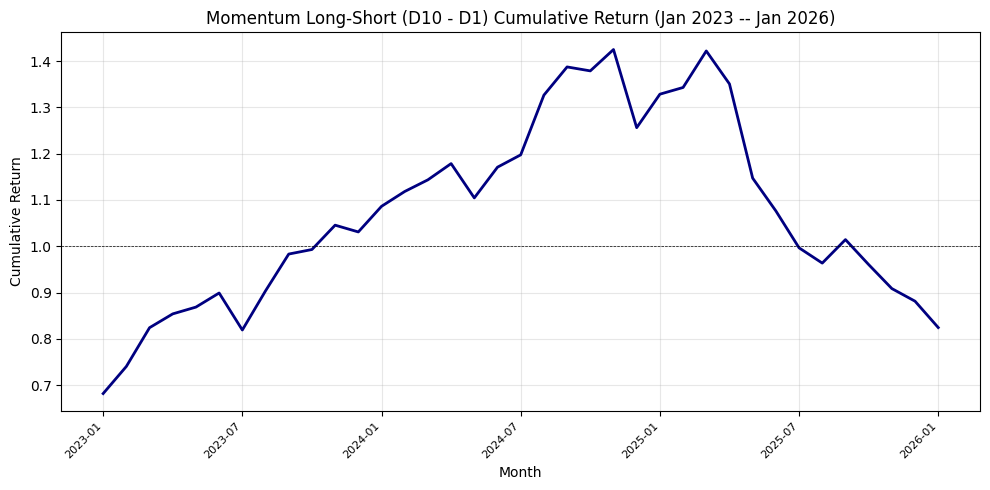

In [7]:
ls_cum = (1 + ls).cumprod()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(ls_cum)), ls_cum, color="navy", linewidth=2)
ax.axhline(1, color="black", linewidth=0.5, linestyle="--")
ax.set_xlabel("Month")
ax.set_ylabel("Cumulative Return")
ax.set_title("Momentum Long-Short (D10 - D1) Cumulative Return (Jan 2023 -- Jan 2026)")

tick_positions = list(range(0, len(ls_cum), 6))
tick_labels = [ls_cum.index[i] for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()